# Slab evolution through the viscosity field — 6-panel figure

Reproduces the multi-panel viscosity-field figure from Cerpa et al. (2022).  Six snapshots arranged 3 rows by 2 columns, each showing $\log_{10}\eta$ over the upper ~700 km of mantle, with a white isotherm contour delineating the cold slab.

Default times span the full simulation (~80 Myr); set `TARGETS_MYR = [2, 6, 14, 22, 44, 62]` to reproduce the original Cerpa panel selection.

## 1. Setup & imports

In [1]:
import numpy as np
if not hasattr(np, 'trapz'): np.trapz = np.trapezoid  # numpy 2.x compat
import glob
import natsort
import matplotlib.pyplot as plt
import pyvista as pv
import warnings, logging
from pathlib import Path

pv.set_error_output_file(Path('/tmp/vtk_errors.log'))
logging.getLogger('pyvista').setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)
warnings.filterwarnings('ignore', message='The VTK reader .*vtkXMLPUnstructuredGridReader.*')

plt.rcParams.update({'mathtext.fontset': 'cm', 'font.family': 'serif'})

## 2. Configuration

Coarser `DX` and deeper `Z_MAX` than the force-balance notebooks — we want the whole upper mantle, not the trench detail.

In [2]:
DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'

MODELS = {
    'STD': dict(folder='STD_RefModel', modname='subduction_with_LM'),
    'WAL': dict(folder='WAL_RefModel', modname='subduction_with_LM'),
}

MODEL_KEY = 'WAL'      # 'STD' or 'WAL'

# === Grid (whole upper mantle + lower-mantle entry) =======================
DX        = 5000.0        # 5 km — coarse enough for whole-domain view; fast
Z_MAX     = 1_500_000.0   # 1500 km — covers slab entry into lower mantle
Y_SURFACE = 2_900_000.0
MIRROR_X  = True          # mirrored frame: subducting plate on right, slab descends leftward

# === Plot crop (mirrored coordinates) =====================================
# Cerpa's original figure crops to model-frame x in [2000, 5000] km (slab on
# the right side of the trench).  In the mirrored frame the equivalent crop
# is x in [3000, 6000] (= 8000 - x_model) — same content, slab descends
# leftward, trench at 4000 (mirror-symmetric).
XLIM_KM = (3000, 6000)
YLIM_KM = (0, 1500)

# === Six target times (Myr) ================================================
# Geometric doubling — emphasises early evolution; ends on the last snapshot.
# Use a positive number to target a specific time, or -1 for the last available
# snapshot regardless of its time.
# Alternatives: [5, 20, 35, 50, 65, 80] (linear), [2, 6, 14, 22, 44, 62] (Cerpa).
TARGETS_MYR = [2, 4, 8, 16, 32, -1]

# === Viscosity colorscale ==================================================
LOG_ETA_MIN = 18.0
LOG_ETA_MAX = 24.0

# === Slab thermal contour ==================================================
T_MANTLE_K   = 1573.15                # potential temperature in the simulation
T_CONTOUR_K  = 0.90 * T_MANTLE_K      # ~1494 K — sharp slab boundary

# === Output ================================================================
figures_dir = Path('../../figures'); figures_dir.mkdir(exist_ok=True)

# === Resolved paths ========================================================
fbase   = DATA_ROOT + MODELS[MODEL_KEY]['folder'] + '/'
modname = MODELS[MODEL_KEY]['modname']
pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu'))
print(f"Model {MODEL_KEY!r}: {len(pvtu_files)} timesteps")

Model 'WAL': 41 timesteps


## 3. Helpers

In [3]:
import sys
_helpers_dir = str(Path('..').resolve())
if _helpers_dir not in sys.path:
    sys.path.insert(0, _helpers_dir)

import sys, os
_r = os.getcwd()
while not os.path.isdir(os.path.join(_r, 'scripts')) and os.path.dirname(_r) != _r:
    _r = os.path.dirname(_r)
if os.path.join(_r, 'scripts') not in sys.path:
    sys.path.insert(0, os.path.join(_r, 'scripts'))
from cerpa_helpers import make_field_extractor

# Try Crameri colormaps first (perceptually uniform, geophysics standard).
# Fallback to matplotlib's RdYlBu_r if cmcrameri isn't installed.
try:
    import cmcrameri.cm as cmc
    CMAP = cmc.batlow_r           # pink -> ochre/green -> dark blue
    print("using cmcrameri.batlow_r")
except ImportError:
    CMAP = plt.get_cmap('RdYlBu_r')   # decent stand-in: red -> yellow -> blue
    print("cmcrameri not installed; using matplotlib RdYlBu_r as fallback")

using cmcrameri.batlow_r


## 4. Pick the six snapshots

Read the time stamp from every PVTU header (cheap — just metadata) and select the snapshots closest to each target.

In [4]:
times_myr = np.empty(len(pvtu_files))
for k, ff in enumerate(pvtu_files):
    vd = pv.read(ff)
    times_myr[k] = float(np.asarray(vd['NormalSP::Time']).flat[0]) / 31_557_600.0 / 1e6
    del vd

# -1 means "use the last snapshot"; positive values pick the nearest snapshot.
selected_idx = []
for tgt in TARGETS_MYR:
    if tgt < 0:
        selected_idx.append(len(pvtu_files) - 1)
    else:
        selected_idx.append(int(np.argmin(np.abs(times_myr - tgt))))

print('selected snapshots:')
for tgt, idx in zip(TARGETS_MYR, selected_idx):
    tgt_str = 'last' if tgt < 0 else f'{tgt:5.1f} Myr'
    print(f'  target {tgt_str:>9}  ->  file [{idx:3d}]  t = {times_myr[idx]:5.2f} Myr')

selected snapshots:
  target   2.0 Myr  ->  file [  1]  t =  2.01 Myr
  target   4.0 Myr  ->  file [  2]  t =  4.01 Myr
  target   8.0 Myr  ->  file [  4]  t =  8.00 Myr
  target  16.0 Myr  ->  file [  8]  t = 16.01 Myr
  target  32.0 Myr  ->  file [ 16]  t = 32.00 Myr
  target      last  ->  file [ 40]  t = 79.95 Myr


## 5. Probe the viscosity field name

Cerpa Fluidity outputs may store viscosity under one of several names — `NormalSP::Viscosity`, `NormalSP::Eta`, etc.  Probe one snapshot and pick the right key.

In [5]:
_probe = pv.read(pvtu_files[selected_idx[0]])
_probe_arrays = list(_probe.array_names)
print('point/cell array names in this PVTU:')
for n in _probe_arrays:
    print(' ', n)

# Auto-detect viscosity
ETA_KEY = None
for cand in ['NormalSP::Viscosity', 'NormalSP::Eta', 'NormalSP::Mu', 'NormalSP::eta']:
    if cand in _probe_arrays:
        ETA_KEY = cand
        break
if ETA_KEY is None:
    raise KeyError(
        'No viscosity field auto-detected.  Inspect the printed array names '
        'above and set ETA_KEY manually in this cell.'
    )
print(f'\nusing ETA_KEY = {ETA_KEY!r}')
del _probe, _probe_arrays

point/cell array names in this PVTU:
  NormalSP::Pressure
  NormalSP::Density
  NormalSP::Temperature
  NormalSP::SecondInvariant_StrainRate
  NormalSP::MaterialVolumeFraction
  NormalSP::FreeSurface
  NormalSP::DeformationMechanism
  NormalSP::Time
  NormalOP::MaterialVolumeFraction
  NormalSP::Velocity
  NormalSP::Viscosity
  NormalSP::Stress
  vtkGhostLevels

using ETA_KEY = 'NormalSP::Viscosity'


## 6. Build the 6-panel figure

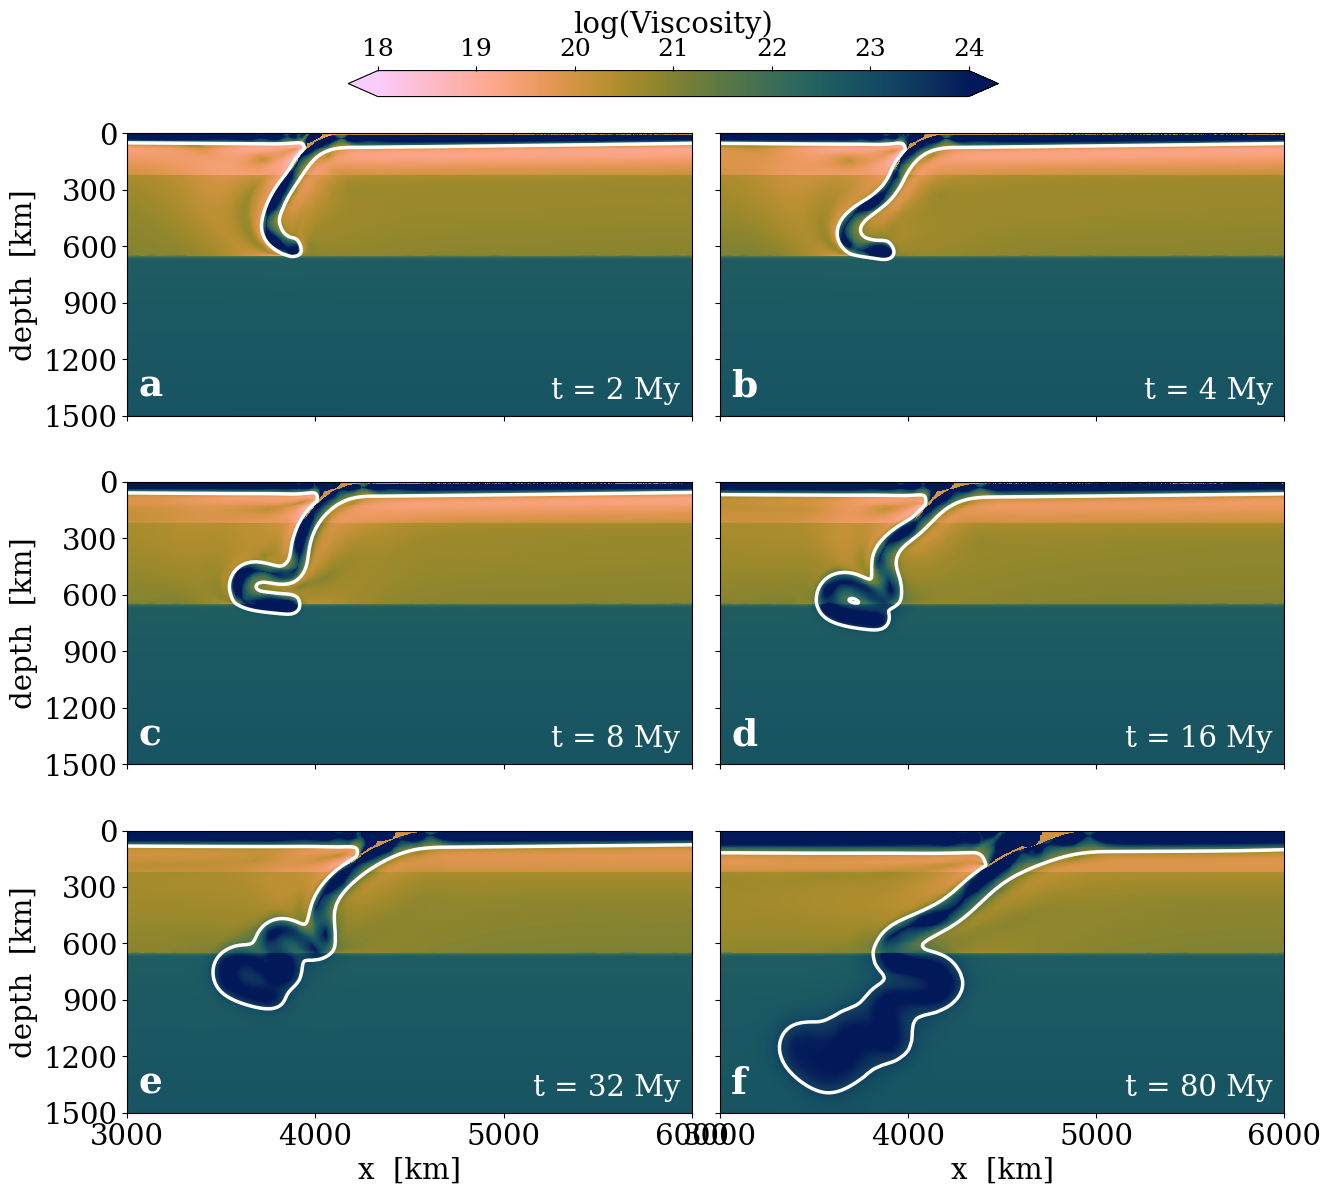

In [6]:
LETTERS = list('abcdef')

fig, axs = plt.subplots(3, 2, figsize=(13, 13), sharex=True, sharey=True)
axs_flat = axs.flatten()

XTICKS = [3000, 4000, 5000, 6000]          # every 1000 km — sparser
YTICKS = [0, 300, 600, 900, 1200, 1500]    # every 300 km, matching Cerpa

im = None
for ax, idx, letter in zip(axs_flat, selected_idx, LETTERS):
    ff = pvtu_files[idx]
    vd = pv.read(ff)
    t_myr = times_myr[idx]

    # Viscosity is stored as a 3x3 tensor (9 components per point) in this
    # Fluidity dataset; take the xx-diagonal (index 0) for the isotropic
    # effective viscosity.  Falls through cleanly if it's already scalar.
    eta_raw = np.asarray(vd[ETA_KEY])
    vd.point_data['eta'] = eta_raw[:, 0] if eta_raw.ndim == 2 else eta_raw
    vd.point_data['T']   = vd['NormalSP::Temperature']

    # --- whole-domain grid ---
    x_min, x_max, _, _, _, _ = vd.bounds
    nx = int((x_max - x_min) / DX); nz = int(Z_MAX / DX)
    x = x_min + (np.arange(nx) + 0.5) * DX
    z = (np.arange(nz) + 0.5) * DX
    X, Z = np.meshgrid(x, z, indexing='xy')
    Y = Y_SURFACE - Z
    grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))
    interp = grid.sample(vd)
    nx_pv, nz_pv, _ = interp.dimensions
    valid = interp['vtkValidPointMask'].reshape((nx_pv, nz_pv), order='F').astype(bool)
    gf = make_field_extractor(interp, nx_pv, nz_pv, valid)

    eta_field = gf('eta')
    T_field   = gf('T')

    if MIRROR_X:
        eta_field = np.flip(eta_field, axis=1)
        T_field   = np.flip(T_field,   axis=1)

    log_eta = np.log10(eta_field)

    # --- viscosity field ---
    im = ax.pcolormesh(x*1e-3, z*1e-3, log_eta,
                       cmap=CMAP, shading='auto',
                       vmin=LOG_ETA_MIN, vmax=LOG_ETA_MAX, rasterized=True)

    # --- slab contour ---
    ax.contour(x*1e-3, z*1e-3, T_field, levels=[T_CONTOUR_K],
               colors='white', linewidths=2.5)

    # --- panel formatting ---
    ax.set_xlim(*XLIM_KM)
    ax.set_ylim(YLIM_KM[1], YLIM_KM[0])   # depth positive down
    ax.set_aspect('equal')
    ax.set_xticks(XTICKS)
    ax.set_yticks(YTICKS)
    ax.tick_params(labelsize=21)
    ax.text(0.02, 0.04, letter, transform=ax.transAxes,
            fontsize=27, fontweight='bold', color='white',
            ha='left', va='bottom')
    ax.text(0.98, 0.04, f't = {round(t_myr)} My', transform=ax.transAxes,
            fontsize=21, color='white',
            ha='right', va='bottom')

    del vd, grid, interp

for ax in axs[-1, :]:
    ax.set_xlabel('x  [km]', fontsize=21)
for ax in axs[:, 0]:
    ax.set_ylabel('depth  [km]', fontsize=21)

# Lock the panel block to the bottom of the figure so the whitespace at the
# top is small and predictable, then place the colorbar just above it.
fig.subplots_adjust(top=0.84, bottom=0.06, left=0.08, right=0.97,
                    hspace=0.10, wspace=0.05)

cbar_ax = fig.add_axes([0.25, 0.855, 0.5, 0.020])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label('log(Viscosity)', fontsize=21)
cbar.ax.tick_params(labelsize=18)
cbar_ax.xaxis.set_ticks_position('top')
cbar_ax.xaxis.set_label_position('top')

fig.savefig(figures_dir / f'viscosity_evolution_6panel_{MODEL_KEY}.png',
            bbox_inches='tight', dpi=180)
plt.show()